# 1.4.4 Smoothing Images

## Kernel Convolution

In [27]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [28]:
l=1
kernel = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]],np.float32)

In [29]:
kernel

array([[ 0., -1.,  0.],
       [-1.,  4., -1.],
       [ 0., -1.,  0.]], dtype=float32)

In [30]:
img = np.random.randint(10, size=(12,12))
#img = np.ones((10,10),np.float32)

In [31]:
img

array([[7, 7, 8, 9, 4, 8, 5, 3, 1, 9, 0, 1],
       [5, 3, 5, 6, 3, 0, 7, 7, 0, 9, 3, 6],
       [5, 9, 0, 2, 9, 1, 5, 7, 1, 0, 5, 1],
       [3, 9, 3, 6, 4, 1, 7, 3, 1, 7, 1, 6],
       [2, 2, 5, 0, 0, 9, 1, 3, 1, 8, 5, 2],
       [1, 2, 9, 6, 2, 2, 5, 5, 9, 9, 7, 7],
       [7, 4, 7, 8, 7, 4, 1, 5, 2, 9, 9, 0],
       [4, 6, 9, 5, 3, 6, 9, 2, 7, 7, 0, 0],
       [2, 3, 0, 0, 2, 0, 4, 7, 2, 3, 8, 1],
       [6, 5, 0, 7, 9, 1, 2, 6, 0, 3, 2, 7],
       [2, 2, 8, 8, 8, 4, 5, 3, 0, 5, 9, 1],
       [6, 0, 1, 6, 9, 3, 3, 3, 9, 4, 7, 4]])

In [32]:
h,w=img.shape

In [33]:
print(h,w)

12 12


In [34]:
#[*range(-2,3)]

In [35]:
dst = np.zeros((h,w),dtype=int)

In [36]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i,j]=t        

In [37]:
img

array([[7, 7, 8, 9, 4, 8, 5, 3, 1, 9, 0, 1],
       [5, 3, 5, 6, 3, 0, 7, 7, 0, 9, 3, 6],
       [5, 9, 0, 2, 9, 1, 5, 7, 1, 0, 5, 1],
       [3, 9, 3, 6, 4, 1, 7, 3, 1, 7, 1, 6],
       [2, 2, 5, 0, 0, 9, 1, 3, 1, 8, 5, 2],
       [1, 2, 9, 6, 2, 2, 5, 5, 9, 9, 7, 7],
       [7, 4, 7, 8, 7, 4, 1, 5, 2, 9, 9, 0],
       [4, 6, 9, 5, 3, 6, 9, 2, 7, 7, 0, 0],
       [2, 3, 0, 0, 2, 0, 4, 7, 2, 3, 8, 1],
       [6, 5, 0, 7, 9, 1, 2, 6, 0, 3, 2, 7],
       [2, 2, 8, 8, 8, 4, 5, 3, 0, 5, 9, 1],
       [6, 0, 1, 6, 9, 3, 3, 3, 9, 4, 7, 4]])

In [38]:
dst

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0, -14,   3,   5,  -7, -19,  11,  11, -18,  24,  -8,   0],
       [  0,  19, -19, -13,  26, -11,  -2,  12,  -4, -22,  15,   0],
       [  0,  19,  -8,  15,   0, -17,  18,  -6,  -8,  18, -19,   0],
       [  0, -10,   6, -17, -15,  32, -20,   2, -17,  10,   2,   0],
       [  0,  -8,  16,   5,  -7, -12,  11,  -2,  19,   3,  -2,   0],
       [  0,  -6,  -2,   7,  11,   0, -19,  10, -22,   9,  20,   0],
       [  0,   4,  18,   0,  -8,   8,  23, -20,  15,   9, -24,   0],
       [  0,  -1, -12, -14,  -4, -13,  -2,  14,  -9,  -8,  26,   0],
       [  0,   9, -20,  11,  18, -11,  -8,  12, -11,   2, -19,   0],
       [  0,  -7,  21,   3,   2,  -1,   8,  -2, -17,   4,  21,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0]])

In [39]:
img = cv2.imread('lena.png', 0)

In [40]:
h,w=img.shape

In [41]:
dst = np.zeros((h-2*l,w-2*l),np.uint8)

In [42]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i-l,j-l]=t 

In [43]:
cv2.imshow('img',img)
cv2.imshow('dst',dst)
cv2.waitKey(0)
cv2.destroyAllWindows()

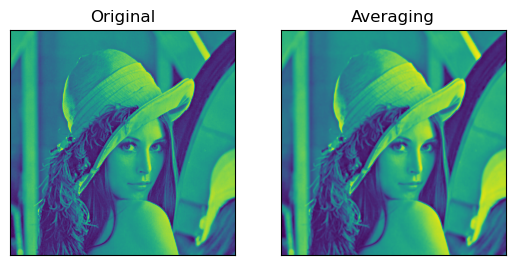

In [45]:
kernel = np.ones((5,5),np.float32)/25
#dst = cv2.filter2D(img,-1,kernel)
blur = cv2.GaussianBlur(img,(5,5),0)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(blur),plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.show()
